# LSTMs for Time Series
---

## Prerequisites
- Knowledge of LSTMs
- Knowledge of Time series

Here, we will conduct time series forecasting using a simple LSTM model. We will use the univariate **'Airline Passengers'** dataset, which contains monthly totals of international airline passengers from 1949 to 1960. This dataset demonstrates both **trend** (increasing passengers over time) and **seasonality** (summer peaks).

## Setup, Data Loading and Exploratory Data Analysis

First, import the necessary libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

Now, let's load the [dataset](https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv) from GitHub.

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
data

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


Now that we loaded the dataset in `data`, we will plot the dataset to see the variations and components of this data.

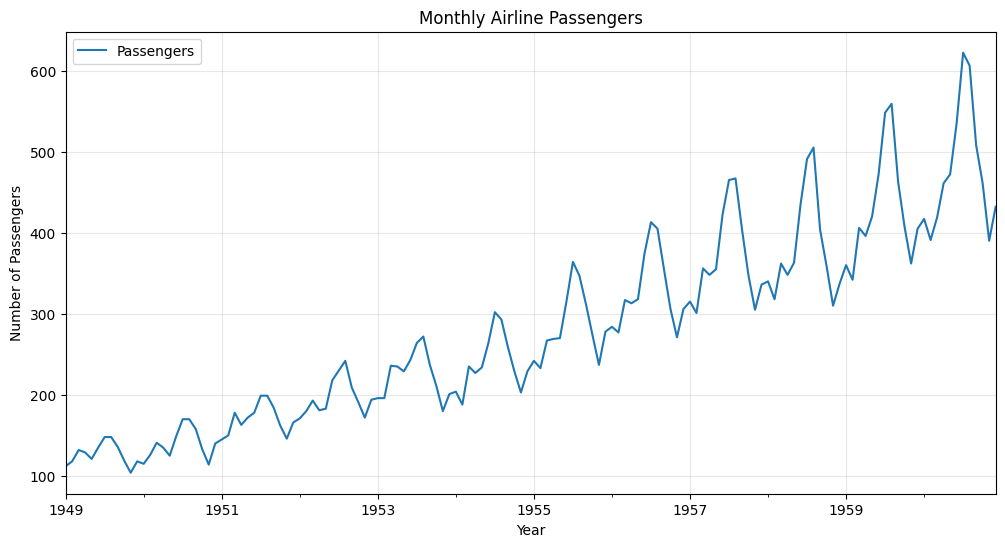

In [3]:
# Plot the dataset
data.plot(figsize=(12,6), title="Monthly Number of Airline Passengers")
plt.title('Monthly Airline Passengers')
plt.ylabel('Number of Passengers')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.show()

This plot shows us that our data has clear **upward trend**, as the amount of passengers constantly increase with time. This data  also has **seasonal cycles**, as the passenger numbers peak every summer.



## Data Preprocessing

### Normalization

LSTMs (and most neural networks) work best when inputs are scaled between 0 and 1.

The normalized inputs prevent large values from dominating the training and ensure stable training.

In [4]:
# Convert to numpy array and normalize
values = data.values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)

### Creating Sequences

Time series is unsupervised in raw form, but supervised learning requires input-target pairs, so let's convert this time series data into a supervised problem by defining a function to create sequences.

We will take the inputs of the last 12 months to predict the next month. This is the **sliding window** method.

Sliding Windows are simple and flexible (window size can be adjusted) and can capture temporal dependencies well. By including multiple past steps, the model can learn both long-term trends and seasonal cycles.



In [5]:
# Function to create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 12
X, y = create_sequences(scaled, SEQ_LENGTH)

Let's convert these to pytorch tensors.

In [6]:
# Convert to PyTorch tensors
import torch

X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()

# Check shapes
print(X.shape, y.shape)

torch.Size([132, 12, 1]) torch.Size([132, 1])


As we can see, the shape of X is [132, 12, 1].
- The dataset `data` has 132 rows
- Each **sequence** that we take to predict the next passenger count has **12** time steps and 1 feature (passengers).
- Target (y) is the next passenger count.

## Define the LSTM model

Now, let's define a simple LSTM model.

Model architecture:

- LSTM layer: learns temporal dependencies.

- Linear layer (fc): maps hidden state to forecast value.

We only take the last timestep output, since that represents the full history.

In [7]:
import torch.nn as nn

class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1):
        super(LSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # take last timestep
        out = self.fc(out)
        return out

model = LSTMForecaster()
print(model)


LSTMForecaster(
  (lstm): LSTM(1, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


Now, let's train the model. Here, we will do so in 200 epochs.

Here, our parameters are:
- Loss Function: MSE (mean squared error), standard for regression tasks, penalize large error more heavily.

- Optimizer: Adam, adaptive learning rate, works well for deep nets.

The training loop is feed forward. We compute loss, backpropagate gradients, update weights in each epoch.

When we run this, we can see that the loss decreases steadily with increasing epochs. This means our LSTM is learning patterns.

In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

EPOCHS = 200

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.6f}")


Epoch 20/200, Loss: 0.022716
Epoch 40/200, Loss: 0.008235
Epoch 60/200, Loss: 0.007064
Epoch 80/200, Loss: 0.006362
Epoch 100/200, Loss: 0.004933
Epoch 120/200, Loss: 0.015072
Epoch 140/200, Loss: 0.004306
Epoch 160/200, Loss: 0.002745
Epoch 180/200, Loss: 0.002314
Epoch 200/200, Loss: 0.002030


Now, let's predict the passenger count and compare actual vs predicted passenger numbers.



In [ ]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X).numpy()

# Inverse scale
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y.numpy())

# Plot
plt.figure(figsize=(12,5))
plt.plot(series.index[SEQ_LENGTH:], y_true, label='Actual')
plt.plot(series.index[SEQ_LENGTH:], y_pred, label='LSTM Forecast')
plt.title("LSTM Forecasting - Univariate Time Series (PyTorch)")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()


As we can see from the graph, our predictions closely follow the  actual values, showing that our LSTM captured **trend** as well as **seasonality**, showing us how LSTMs can be used for Time Series Forecasting.

## References

[LSTM for Time Series Forecasting](https://machinelearningmastery.com/time-series-forecasting-long-short-term-memory-network-python/)